## DART - LightGBM

**Objetivo:** desenvolver um modelo de previsão de PM2.5 utilizando o DART(Dropouts meet Multiple Additive Regression Trees), implementado no LightGBM, incorporando variáveis meteorológicas, atributos temporais e informações históricas da série para previsão das próximas 24 horas.

*******
**Exploração e entendimento dos dados**
- Avaliando ciclos sazonais e correlação entre variáveis
- Análise de correlação entre as variáveis meteorológicas e a concentração de PM2.5;
- Avaliação da multicolinearidade por meio do VIF (Variance Inflation Factor);
- Análise da estacionariedade da série temporal;
- Investigação da influência de lags temporais e padrões sazonais sobre a variável alvo.

************

**Experimentos DART/LightGBM**

Foram realizados diversos experimentos com o modelo DART/LightGBM para previsão de PM2.5 com horizonte de 24 horas. Os testes avaliaram diferentes configurações de:

- Estratégias de tratamento de dados faltantes (sem interpolação, interpolação para gaps menores que 12 horas e preenchimento por média);
- Inclusão de variáveis meteorológicas (temperatura, umidade relativa, precipitação e velocidade do vento);
- Inclusão de atributos temporais cíclicos (mês, dia da semana e hora representados por funções seno e cosseno);
- Inclusão de séries de Fourier para representação de sazonalidades de longo prazo;
- Diferentes conjuntos de lags da variável PM2.5 (últimas horas, mesmo horário do dia anterior e mesma hora da semana anterior);
- Ajuste dos hiperparâmetros do modelo, incluindo número de árvores, taxa de aprendizado, profundidade máxima, número de folhas e parâmetros específicos do algoritmo DART.

************

**Conjunto de dados base utilizado**

      - 100% dos dados entre 2016-2019
      - train: (16104, 7) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
      - val  : (8760, 7) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
      - test : (5499, 7) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00

************

**Melhor Experimento -------- atualizar**



In [1]:
%matplotlib widget

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

### 1. Carregamento dos dados

In [3]:
# abrindo base de dados para treinamento/teste/validação
data = pd.read_csv("../data/data_sem_interpolacao/dados_full_feature_2016_2019_nan.csv")
data.head()

,time,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
1,2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2,2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
3,2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
4,2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


In [4]:
data["time"] = pd.to_datetime(data["time"])
data = data.set_index("time").sort_index()

data.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
time,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984


### 2. Exploração da Série Temporal (Ciclos)

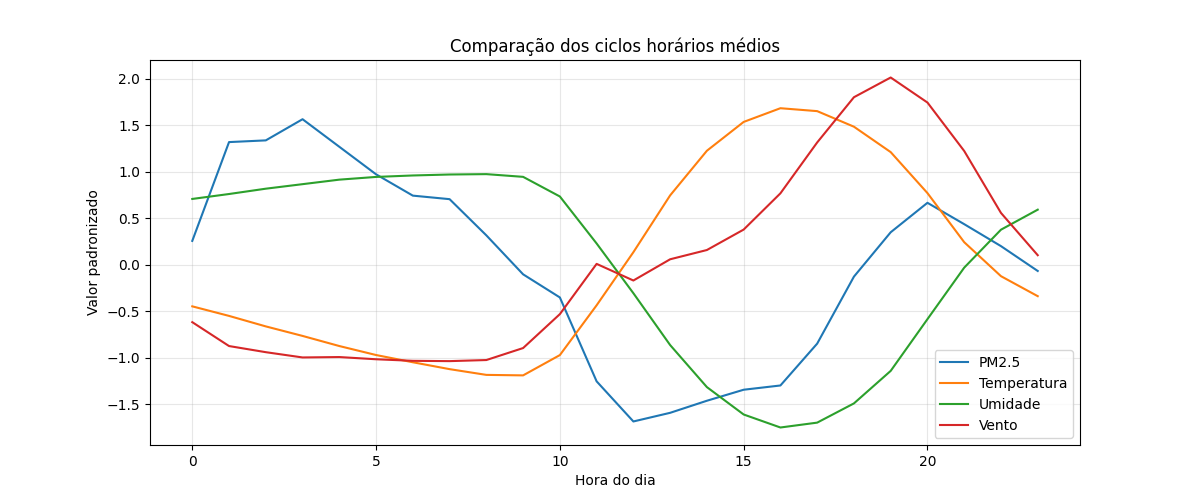

In [5]:
#ciclo diário
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.hour)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.hour)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.hour)["relative_humidity_2m"].mean(),
    "Vento": data.groupby(data.index.hour)["wind_speed_10m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos horários médios")
ax.set_xlabel("Hora do dia")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.show()

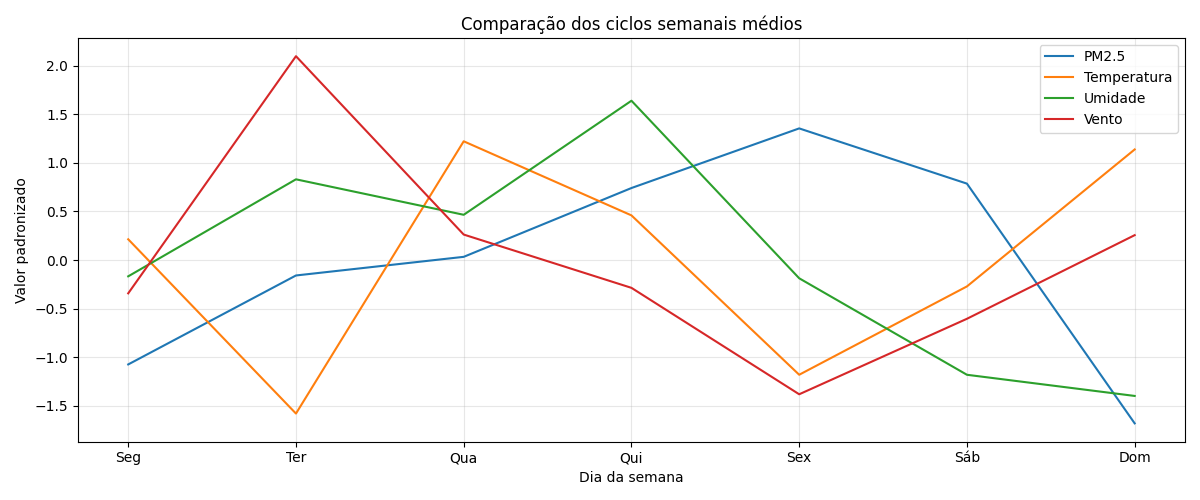

In [6]:
# ciclo semanal
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.dayofweek)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.dayofweek)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.dayofweek)["relative_humidity_2m"].mean(),
    "Vento": data.groupby(data.index.dayofweek)["wind_speed_10m"].mean()
})

ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
ciclo_norm.index = dias

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos semanais médios")
ax.set_xlabel("Dia da semana")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

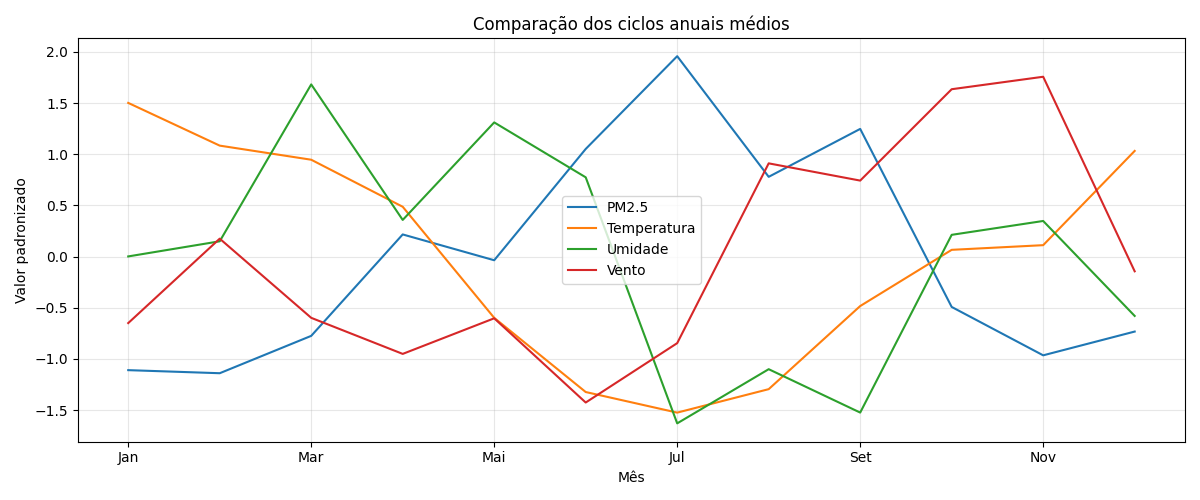

In [7]:
# ciclo anual
ciclo = pd.DataFrame({
    "PM2.5": data.groupby(data.index.month)["MP2.5"].mean(),
    "Temperatura": data.groupby(data.index.month)["temperature_2m"].mean(),
    "Umidade": data.groupby(data.index.month)["relative_humidity_2m"].mean(),
    "Vento": data.groupby(data.index.month)["wind_speed_10m"].mean()
})


ciclo_norm = pd.DataFrame(
    StandardScaler().fit_transform(ciclo),
    index=ciclo.index,
    columns=ciclo.columns
)

meses = [
    "Jan", "Fev", "Mar", "Abr",
    "Mai", "Jun", "Jul", "Ago",
    "Set", "Out", "Nov", "Dez"
]

ciclo_norm.index = meses

fig, ax = plt.subplots(figsize=(12,5))

ciclo_norm.plot(ax=ax)

ax.set_title("Comparação dos ciclos anuais médios")
ax.set_xlabel("Mês")
ax.set_ylabel("Valor padronizado")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Correlação entre variáveis

In [8]:
######### Temperatura e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_temp = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["temperature_2m"].shift(lag)
    )

    corr_temp.append(c)

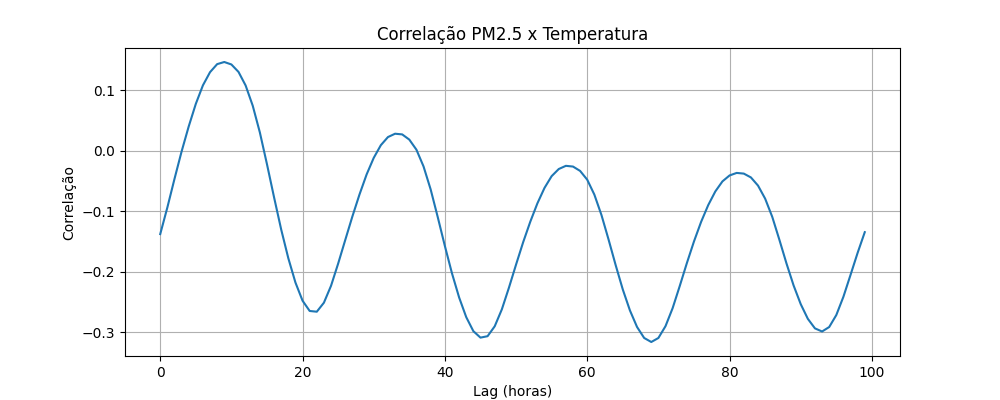

In [9]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_temp)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Temperatura")
plt.grid()

plt.show()

In [10]:
######### umidade e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_umi = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["relative_humidity_2m"].shift(lag)
    )

    corr_umi.append(c)

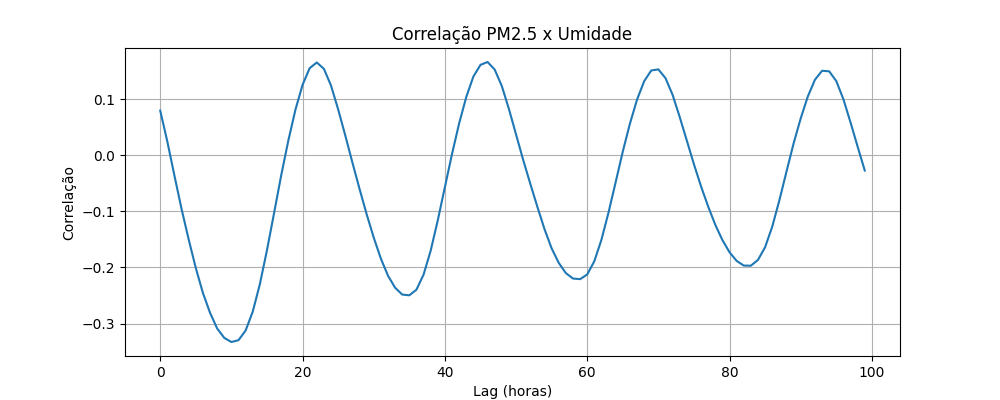

In [11]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_umi)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Umidade")
plt.grid()

plt.show()

In [12]:
corr_pm25 = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["MP2.5"].shift(lag)
    )

    corr_pm25.append(c)

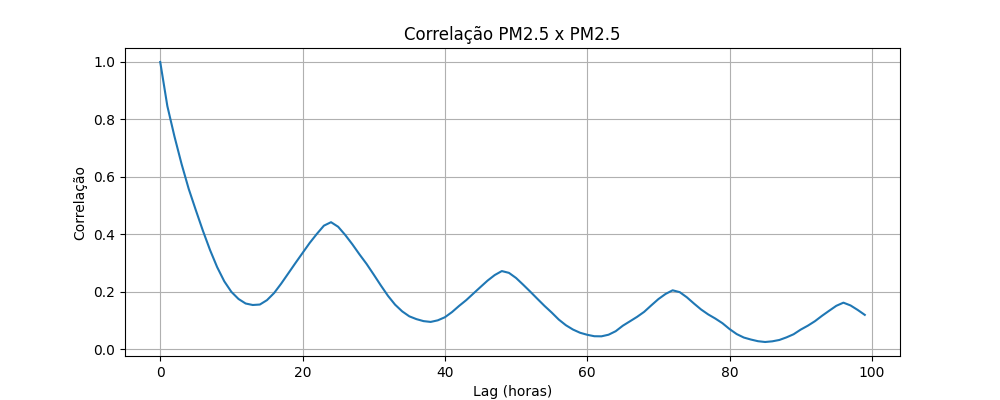

In [13]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_pm25)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x PM2.5")
plt.grid()

plt.show()

In [14]:
######### vento e PM25
# correlação cruzada consideranod lag (temperatura e PM25)
corr_vento = []

for lag in range(0, 100):

    c = data["MP2.5"].corr(
        data["wind_speed_10m"].shift(lag)
    )

    corr_vento.append(c)

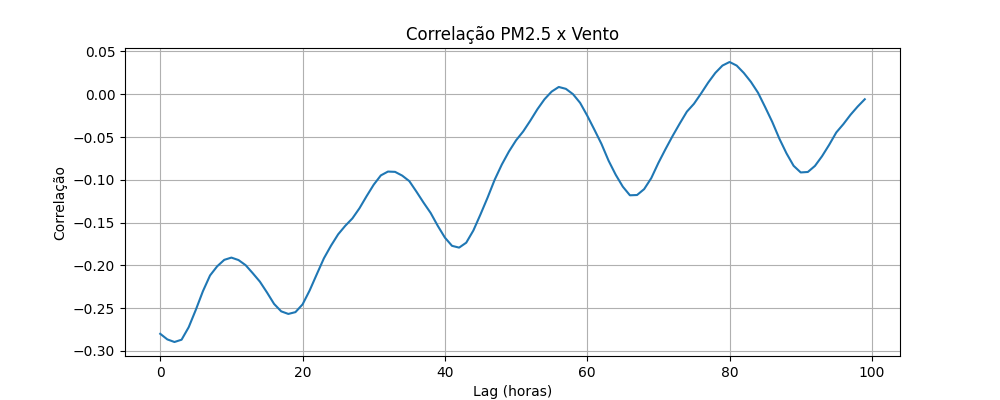

In [15]:
plt.figure(figsize=(10,4))

plt.plot(range(100), corr_vento)

plt.xlabel("Lag (horas)")
plt.ylabel("Correlação")
plt.title("Correlação PM2.5 x Vento")
plt.grid()

plt.show()

**Entendendo variabilidade anual**

In [16]:
pm25_mes = (data.groupby(data.index.month)["MP2.5"].mean())

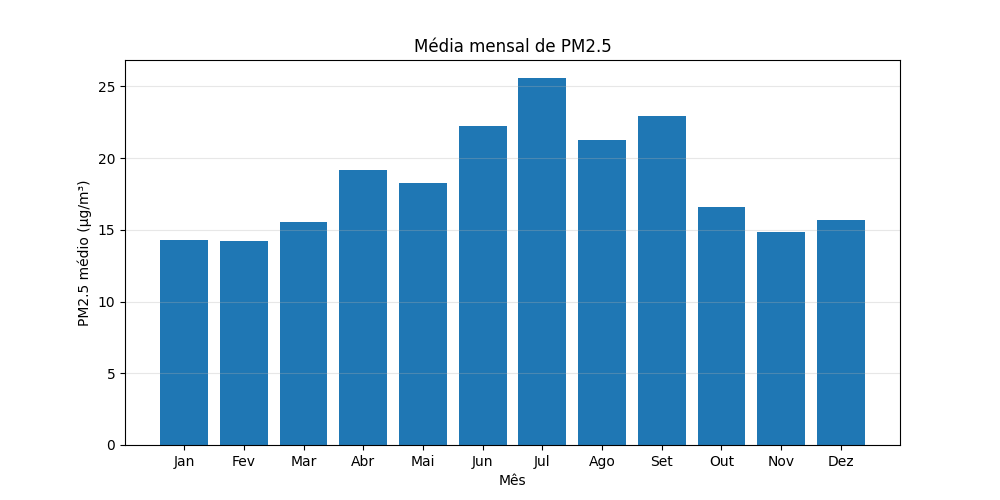

In [17]:
import matplotlib.pyplot as plt

meses = [
    "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
    "Jul", "Ago", "Set", "Out", "Nov", "Dez"
]

plt.figure(figsize=(10,5))

plt.bar(
    meses,
    pm25_mes
)

plt.ylabel("PM2.5 médio (µg/m³)")
plt.xlabel("Mês")
plt.title("Média mensal de PM2.5")
plt.grid(axis="y", alpha=0.3)

plt.show()

### 4. Feature Engineering

In [18]:
data_lgbm = data.copy()

**Variáveis ciclicas temporais**

In [19]:
# Foram avaliadas diferentes features sazonais (ciclos diários, semanais e mensal) com o objetivo de melhorar a reprodução do modelo.
def cyclical_time_features(df):
    """
    Adiciona termos ciclicos como features exógenas
    df -> data

    """

    df = df.copy()

    df["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
    df["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)


    df["weekday_sin"] = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df.index.dayofweek / 7)


    df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)

    return df

In [20]:
data_lgbm = cyclical_time_features(data_lgbm)

In [21]:
data_lgbm.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,hour_cos
time,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,1.000000
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,0.965926
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,0.866025
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,0.707107
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,0.500000


**Variáveis meteorológicas com lags**

In [22]:
# vou usar apenas temperatura, vento e umidade que parecem ter maior corelação com lag
met_vars = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
]

for var in met_vars:
    if var in data_lgbm.columns:
        for lag in [1, 3, 6, 12, 24]:
            data_lgbm[f"{var}_lag{lag}"] = data_lgbm[var].shift(lag)

data_lgbm.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,...,relative_humidity_2m_lag1,relative_humidity_2m_lag3,relative_humidity_2m_lag6,relative_humidity_2m_lag12,relative_humidity_2m_lag24,wind_speed_10m_lag1,wind_speed_10m_lag3,wind_speed_10m_lag6,wind_speed_10m_lag12,wind_speed_10m_lag24
time,,,,,,,,,,,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,...,95.075165,NaN,NaN,NaN,NaN,12.538134,NaN,NaN,NaN,NaN
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,...,95.983490,NaN,NaN,NaN,NaN,14.529915,NaN,NaN,NaN,NaN
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,...,95.380060,95.075165,NaN,NaN,NaN,12.538134,12.538134,NaN,NaN,NaN
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,...,96.285950,95.983490,NaN,NaN,NaN,11.525623,14.529915,NaN,NaN,NaN


In [23]:
# lag negativo = valor futuro da variável meteorológica
# na ferramenta operacional terei acesso às previsões atmosféricas.
# for var in ["temperature_2m", "relative_humidity_2m", "wind_speed_10m"]:
#     for h in [1, 3, 6, 12, 24]:
#         data_lgbm[f"{var}_future{h}"] = data_lgbm[var].shift(-h)

**Lags temporais do target (MP2.5)**

In [24]:
for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
    data_lgbm[f"pm25_lag{lag}"] = data_lgbm["MP2.5"].shift(lag)

data_lgbm.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,...,wind_speed_10m_lag12,wind_speed_10m_lag24,pm25_lag1,pm25_lag2,pm25_lag3,pm25_lag6,pm25_lag12,pm25_lag24,pm25_lag48,pm25_lag168
time,,,,,,,,,,,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,...,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,...,NaN,NaN,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,...,NaN,NaN,18.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,...,NaN,NaN,17.0,18.0,1.0,NaN,NaN,NaN,NaN,NaN


**indicador de inverno (mês de poluição mais extrema)**

In [25]:
# a reprodução dos meses de inverno teve o pior desempenho no SARIMAX
data_lgbm["is_winter"] = data_lgbm.index.month.isin([6, 7, 8]).astype(int)
data_lgbm.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,...,wind_speed_10m_lag24,pm25_lag1,pm25_lag2,pm25_lag3,pm25_lag6,pm25_lag12,pm25_lag24,pm25_lag48,pm25_lag168,is_winter
time,,,,,,,,,,,,,,,,,,,,,
2016-03-01 00:00:00+00:00,3.0,17.851000,95.075165,1.0,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2016-03-01 01:00:00+00:00,1.0,17.901001,95.983490,0.4,14.529915,1.0,6.123234e-17,0.781831,0.62349,0.258819,...,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2016-03-01 02:00:00+00:00,18.0,17.951000,95.380060,0.3,12.538134,1.0,6.123234e-17,0.781831,0.62349,0.500000,...,NaN,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,0
2016-03-01 03:00:00+00:00,17.0,17.851000,96.285950,0.6,11.525623,1.0,6.123234e-17,0.781831,0.62349,0.707107,...,NaN,18.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,0
2016-03-01 04:00:00+00:00,10.0,17.901001,95.983490,0.5,12.979984,1.0,6.123234e-17,0.781831,0.62349,0.866025,...,NaN,17.0,18.0,1.0,NaN,NaN,NaN,NaN,NaN,0


**Janela móvel (rolling)**

In [26]:
for window in [6, 12, 24, 48]:
    base = data_lgbm["MP2.5"].shift(1)
    data_lgbm[f"pm25_mean_{window}h"] = base.rolling(window).mean()
    data_lgbm[f"pm25_std_{window}h"]  = base.rolling(window).std()
    data_lgbm[f"pm25_max_{window}h"]  = base.rolling(window).max()

data_lgbm.shape

(30363, 47)

### 5. Separando conjunto de treino, validação e teste

In [27]:
def split_temporal_lgbm(
    df,
    target,
    train_end="2018-01-01",
    val_end="2019-01-01"
):
    """
    Separação do conjunto de dados em: Treino, Teste e Validação

    """

    df = df.copy()
    df = df.sort_index()

    feature_cols = [c for c in df.columns if c != target]

    train = df.loc[df.index < train_end].copy()
    val = df.loc[(df.index >= train_end) & (df.index < val_end)].copy()
    test = df.loc[df.index >= val_end].copy()

    X_train, y_train = train[feature_cols], train[target]
    X_val,   y_val   = val[feature_cols],   val[target]
    X_test,  y_test  = test[feature_cols],  test[target]

    print("train:", train.shape, train.index.min(), train.index.max())
    print("val  :", val.shape,   val.index.min(),   val.index.max())
    print("test :", test.shape,  test.index.min(),  test.index.max())


    return X_train, X_val, X_test, y_train, y_val, y_test

In [28]:
X_train, X_val, X_test, y_train, y_val, y_test = split_temporal_lgbm(
    data_lgbm,
    target="MP2.5",
    train_end="2018-01-01",
    val_end="2019-01-01"
)


train: (16104, 47) 2016-03-01 00:00:00+00:00 2017-12-31 23:00:00+00:00
val  : (8760, 47) 2018-01-01 00:00:00+00:00 2018-12-31 23:00:00+00:00
test : (5499, 47) 2019-01-01 00:00:00+00:00 2019-08-18 02:00:00+00:00


In [29]:
X_train.shape, y_train.shape

((16104, 46), (16104,))

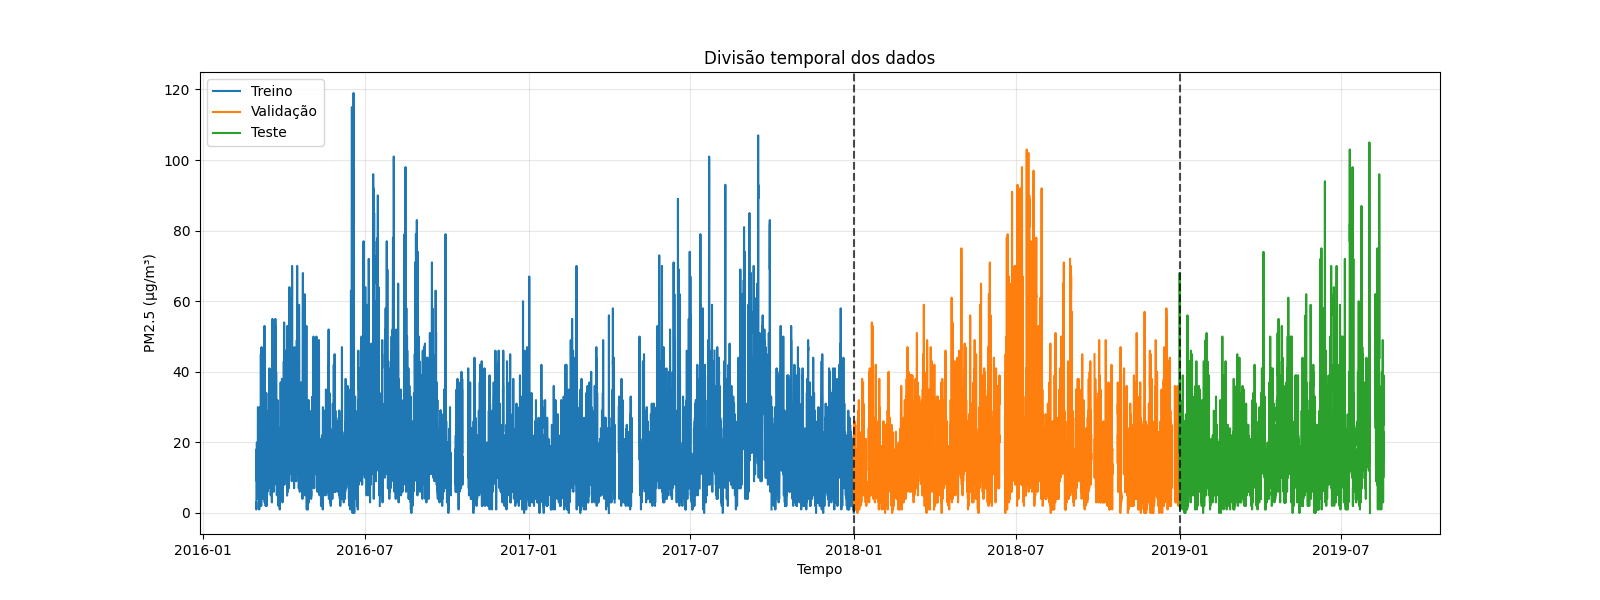

In [30]:
plt.figure(figsize=(16,6))

plt.plot(
    y_train,
    label="Treino",
    color="tab:blue"
)

plt.plot(
    y_val,
    label="Validação",
    color="tab:orange"
)

plt.plot(
    y_test,
    label="Teste",
    color="tab:green"
)

plt.axvline(
    y_val.index[0],
    color="black",
    linestyle="--",
    alpha=0.7
)

plt.axvline(
    y_test.index[0],
    color="black",
    linestyle="--",
    alpha=0.7
)

plt.title("Divisão temporal dos dados")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Tempo")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 6. Baseline simples

In [31]:
# Seasonal Naive (24h) - utilizado nas rodas simples do modelo (item 9.1)
# observado nas primeiras 24h do teste
y_true = y_val.iloc[:24]

# Baseline = ultimas 24h do treino
y_baseline = y_train.iloc[-24:].copy()

y_baseline.index = y_true.index

mae_baseline = mean_absolute_error(y_true, y_baseline)
rmse_baseline = root_mean_squared_error(y_true, y_baseline)
r2_baseline = r2_score(y_true, y_baseline)

print(f"Baseline 24h - MAE : {mae_baseline:.3f}")
print(f"Baseline 24h - RMSE: {rmse_baseline:.3f}")
print(f"Baseline 24h - R²  : {r2_baseline:.3f}")

Baseline 24h - MAE : 5.375
Baseline 24h - RMSE: 7.536
Baseline 24h - R²  : -0.304


### 7. Modelagem

**7.1 Modelo único para testes**

In [32]:
model = LGBMRegressor()

In [33]:
results =  model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric="mae",
    eval_names=["treino", "validação"]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001584 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7886
[LightGBM] [Info] Number of data points in the train set: 16104, number of used features: 46
[LightGBM] [Info] Start training from score 18.029123


In [34]:
#  Feature importance — diagnóstico do modelo

def plot_feature_importance(model, X_train, top_n=20):
    """
    Equivalente à análise de resíduos do SARIMAX —
    mostra quais features o modelo está usando de fato.
    """
    imp = pd.Series(
        model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    imp.plot(kind="barh", ax=ax)
    ax.invert_yaxis()
    ax.set_title(f"Feature Importance — Top {top_n}")
    ax.set_xlabel("Importância")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return imp

In [35]:
def prever_24h(model, X_val, horizon=24):
    """
    Previsão das próximas 24h — usa features já calculadas.
    Equivalente ao get_forecast do SARIMAX.
    """
    X_future = X_val.iloc[:horizon]
    y_pred   = model.predict(X_future)

    return pd.Series(y_pred, index=X_future.index, name="forecast")

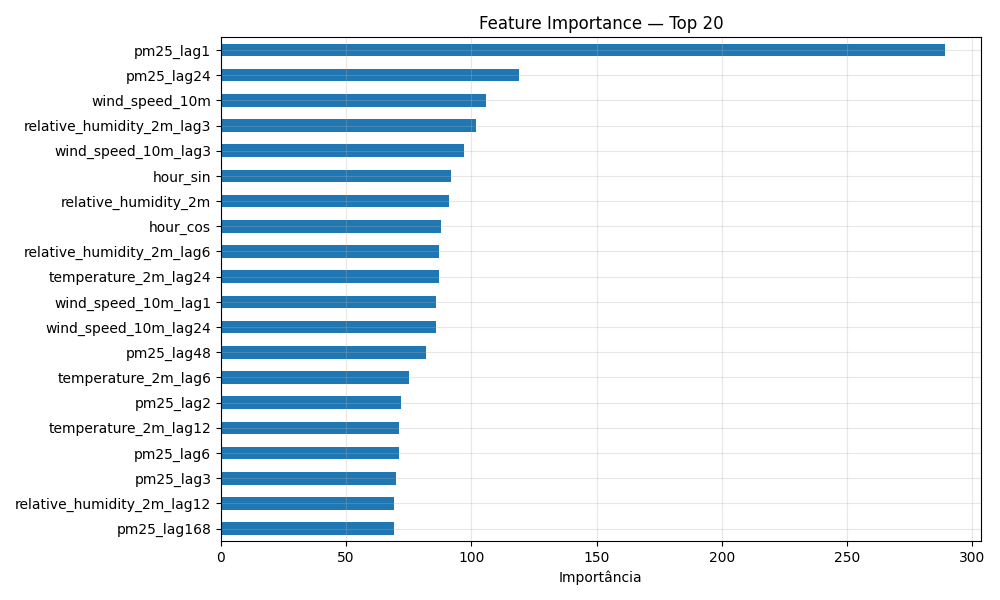

In [36]:
# feature importance
plot_feature_importance(results, X_train);


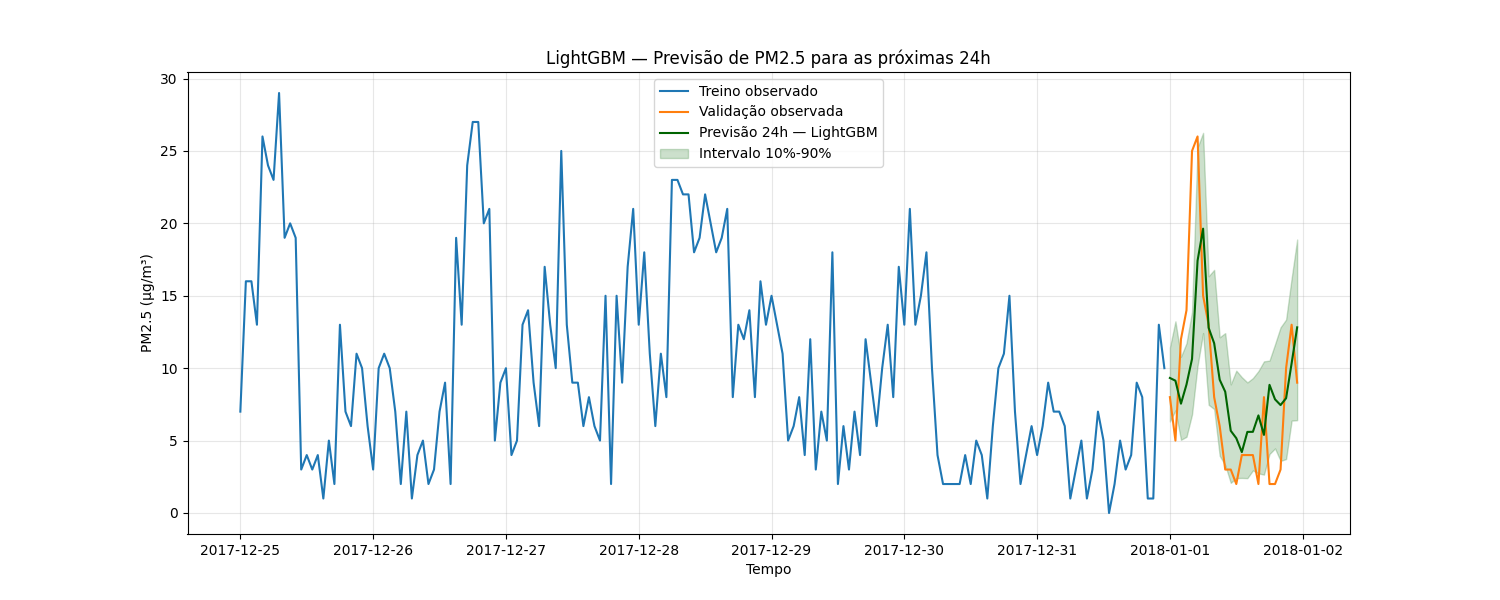

In [37]:
# treina dois modelos adicionais para os quantis
model_q10 = LGBMRegressor(objective="quantile", alpha=0.1,
                           n_estimators=500, random_state=42, verbose=-1)
model_q90 = LGBMRegressor(objective="quantile", alpha=0.9,
                           n_estimators=500, random_state=42, verbose=-1)

model_q10.fit(X_train, y_train)
model_q90.fit(X_train, y_train)

X_future  = X_val.iloc[:24]
pred_mean = pd.Series(model.predict(X_future),    index=X_future.index)
pred_low  = pd.Series(model_q10.predict(X_future), index=X_future.index)
pred_high = pd.Series(model_q90.predict(X_future), index=X_future.index)


plt.figure(figsize=(15, 6))

plt.plot(y_train.iloc[-24*7:], label="Treino observado")
plt.plot(y_val.iloc[:24],      label="Validação observada")
plt.plot(pred_mean, label="Previsão 24h — LightGBM", color="darkgreen")

plt.fill_between(
    pred_mean.index,
    pred_low,
    pred_high,
    alpha=0.2,
    color="darkgreen",
    label="Intervalo 10%-90%"
)

plt.title("LightGBM — Previsão de PM2.5 para as próximas 24h")
plt.xlabel("Tempo")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [38]:
error_mae = mean_absolute_error(
                y_true = y_val.iloc[:24],
                y_pred = pred_mean
            )
print(f"Test error (mae): {error_mae}")

Test error (mae): 4.059344425228066


In [39]:
error_rmse = root_mean_squared_error(
    y_true=y_val.iloc[:24],
    y_pred=pred_mean
)

print(f"Test error (RMSE): {error_rmse:.3f}")

Test error (RMSE): 4.991


In [40]:
r2 = r2_score(
    y_true=y_val.iloc[:24],
    y_pred=pred_mean
)

print(f"R²: {r2:.4f}")

R²: 0.4283


**Learning Curve — LightGBM**

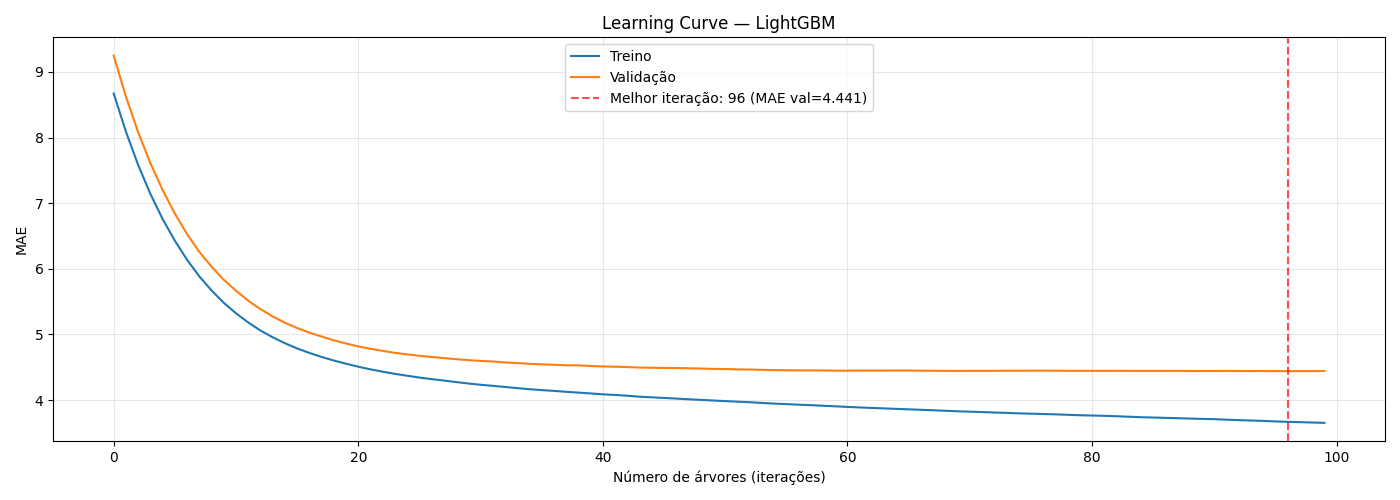

Melhor iteração : 96
MAE treino      : 3.669
MAE validação   : 4.441
Gap treino/val  : 0.772  (ideal próximo de 0)


In [41]:
# extraindo métricas por iteração
mae_train = model.evals_result_["treino"]["l1"]
mae_val   = model.evals_result_["validação"]["l1"]


fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(mae_train, label="Treino",    color="tab:blue",   linewidth=1.5)
ax.plot(mae_val,   label="Validação", color="tab:orange", linewidth=1.5)


best_iter = np.argmin(mae_val)
ax.axvline(best_iter, color="red", linestyle="--", alpha=0.7,
           label=f"Melhor iteração: {best_iter} (MAE val={mae_val[best_iter]:.3f})")

ax.set_title("Learning Curve — LightGBM")
ax.set_xlabel("Número de árvores (iterações)")
ax.set_ylabel("MAE")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Melhor iteração : {best_iter}")
print(f"MAE treino      : {mae_train[best_iter]:.3f}")
print(f"MAE validação   : {mae_val[best_iter]:.3f}")
print(f"Gap treino/val  : {mae_val[best_iter] - mae_train[best_iter]:.3f}  (ideal próximo de 0)")

**7.2 Avaliação de todo o conjunto de validação** 

In [42]:
def walk_forward_lgbm(
    X_train, y_train,
    X_test,  y_test,
    horizon=24,
    step=24*7,
    start_inicial=0,
    output_file="walk_forward_lgbm.csv"
):
    """
    Walk-forward validation para LightGBM.
    Estrutura idêntica ao walk_forward_sarimax.
    """

    resultados = []

    X_total = pd.concat([X_train, X_test])
    y_total = pd.concat([y_train, y_test])

    n_test = len(y_test)

    for start in range(start_inicial, n_test - horizon + 1, step):

        print(f"Rodando previsão {start} até {start + horizon} de {n_test}...")

        # treino cresce a cada iteração
        X_train_i = X_total.iloc[:len(X_train) + start]
        y_train_i = y_total.iloc[:len(y_train) + start]

        # janela futura
        X_true_i = X_test.iloc[start:start + horizon]
        y_true_i = y_test.iloc[start:start + horizon]

        mask_eval = y_true_i.notna()

        if mask_eval.sum() == 0:
            continue


        mask_train = X_train_i.notna().all(axis=1)
        X_fit = X_train_i[mask_train]
        y_fit = y_train_i[mask_train]


        model_i = LGBMRegressor(n_estimators=100,verbose=-1)

        model_i.fit(X_fit, y_fit)

        y_pred_i = pd.Series(
            model_i.predict(X_true_i),
            index=y_true_i.index
        )

        # baseline: últimas 24h observadas
        y_baseline_i = y_total.iloc[
            len(y_train) + start - horizon : len(y_train) + start
        ].copy()
        y_baseline_i.index = y_true_i.index

        mask_eval = y_true_i.notna() & y_baseline_i.notna()

        if mask_eval.sum() == 0:
            continue

        # métricas do modelo
        mae  = mean_absolute_error(y_true_i[mask_eval], y_pred_i[mask_eval])
        rmse = np.sqrt(mean_squared_error(y_true_i[mask_eval], y_pred_i[mask_eval]))
        r2   = r2_score(y_true_i[mask_eval], y_pred_i[mask_eval]) \
               if mask_eval.sum() > 1 else np.nan

        # métricas do baseline
        mae_baseline  = mean_absolute_error(y_true_i[mask_eval], y_baseline_i[mask_eval])
        rmse_baseline = np.sqrt(mean_squared_error(y_true_i[mask_eval], y_baseline_i[mask_eval]))
        r2_baseline   = r2_score(y_true_i[mask_eval], y_baseline_i[mask_eval]) \
                        if mask_eval.sum() > 1 else np.nan

        melhora_mae  = 100 * (mae_baseline - mae)  / mae_baseline  if mae_baseline  != 0 else np.nan
        melhora_rmse = 100 * (rmse_baseline - rmse) / rmse_baseline if rmse_baseline != 0 else np.nan

        resultados.append({
            "start"           : start,
            "inicio_previsao" : y_true_i.index[0],
            "fim_previsao"    : y_true_i.index[-1],
            "mes"             : str(y_true_i.index[0].to_period("M")),
            "n_obs"           : mask_eval.sum(),

            "mae_lgbm"        : mae,
            "rmse_lgbm"       : rmse,
            "r2_lgbm"         : r2,

            "mae_baseline"    : mae_baseline,
            "rmse_baseline"   : rmse_baseline,
            "r2_baseline"     : r2_baseline,

            "melhora_mae_%"   : melhora_mae,
            "melhora_rmse_%"  : melhora_rmse
        })

        pd.DataFrame(resultados).to_csv(output_file, index=False)

    return pd.DataFrame(resultados)

In [43]:
df_walk_val = walk_forward_lgbm(
    X_train, y_train,
    X_val,   y_val,
    horizon=24,
    step=24*7,
    output_file="../results/walk_forward_lgbm_val.csv"
)

Rodando previsão 0 até 24 de 8760...


/tmp/ipykernel_251334/177101624.py:83: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 168 até 192 de 8760...


/tmp/ipykernel_251334/177101624.py:83: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 336 até 360 de 8760...
Rodando previsão 504 até 528 de 8760...


...

/tmp/ipykernel_251334/177101624.py:83: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 8400 até 8424 de 8760...


/tmp/ipykernel_251334/177101624.py:83: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


Rodando previsão 8568 até 8592 de 8760...
Rodando previsão 8736 até 8760 de 8760...


/tmp/ipykernel_251334/177101624.py:83: UserWarning: Converting to Period representation will drop timezone information.
  "mes"             : str(y_true_i.index[0].to_period("M")),


In [44]:
df_walk_val[["mae_lgbm", "rmse_lgbm", "r2_lgbm",
         "mae_baseline", "melhora_mae_%"]].describe()

,mae_lgbm,rmse_lgbm,r2_lgbm,mae_baseline,melhora_mae_%
count,48.000000,48.000000,48.000000,48.000000,48.000000
mean,4.346496,5.576074,0.338110,8.469467,43.429625
std,1.269127,1.733852,0.286306,3.998367,16.796995
min,1.523643,1.526512,-0.332658,3.500000,7.939293
25%,3.525127,4.474895,0.119849,5.645833,32.756638
50%,4.089703,5.302049,0.385996,7.666667,44.424777
75%,4.935920,6.427782,0.547079,9.958333,57.333609
max,7.294682,11.331025,0.903991,23.541667,79.618269


**Comparando com o melhor SARIMAX**

In [45]:
#abrindo resultados do conjunto de validação
best_sarimax = pd.read_csv('../results/walk_forward_parcial_temp_umi_prec_wind_101_val.csv')
best_sarimax["inicio_previsao"] = pd.to_datetime(best_sarimax["inicio_previsao"])

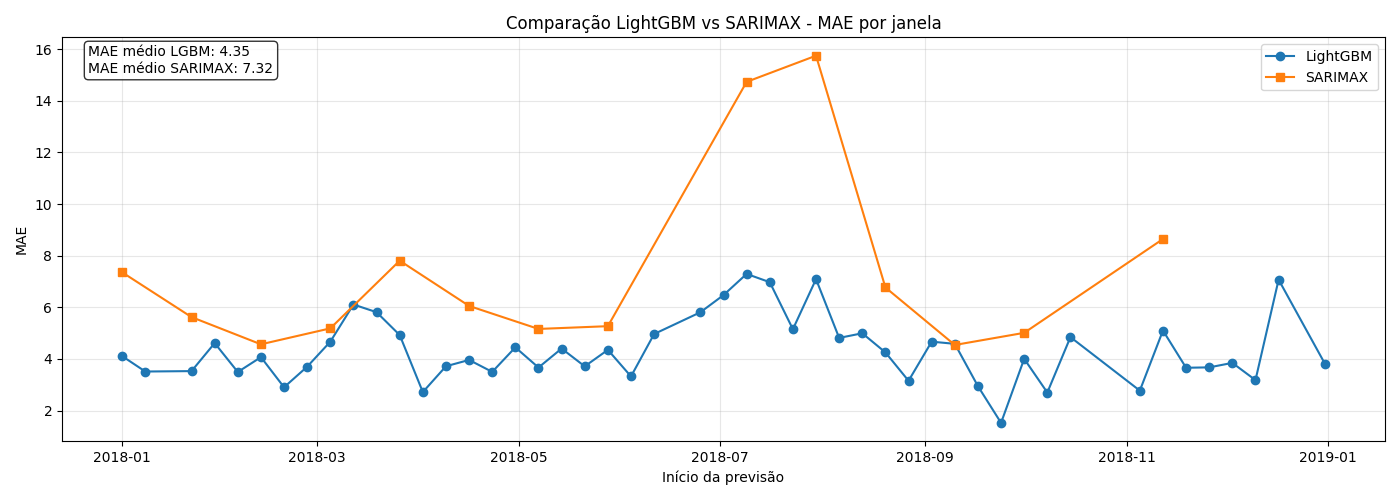

In [46]:
mae_lgbm = df_walk_val["mae_lgbm"].mean()
mae_sarimax = best_sarimax["mae_sarimax"].mean()

plt.figure(figsize=(14, 5))

plt.plot(
    df_walk_val["inicio_previsao"],
    df_walk_val["mae_lgbm"],
    marker="o",
    label="LightGBM"
)

plt.plot(
    best_sarimax["inicio_previsao"],
    best_sarimax["mae_sarimax"],
    marker="s",
    label="SARIMAX"
)

texto = (
    f"MAE médio LGBM: {mae_lgbm:.2f}\n"
    f"MAE médio SARIMAX: {mae_sarimax:.2f}"
)

plt.text(
    0.02,          # posição horizontal (% do gráfico)
    0.98,          # posição vertical (% do gráfico)
    texto,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        alpha=0.8
    )
)

plt.title("Comparação LightGBM vs SARIMAX - MAE por janela")
plt.xlabel("Início da previsão")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

**SearchGRID**

In [47]:
# # espaço de busca
# param_grid = {
#     "learning_rate"    : [0.01, 0.05, 0.1],
#     "num_leaves"       : [31, 63],
#     "min_child_samples": [10, 20, 50],
#     "subsample"        : [0.6, 0.8, 1.0],
#     "colsample_bytree" : [0.6, 0.8, 1.0],
# }

# # TimeSeriesSplit — respeita ordem temporal
# # n_splits=5 cria 5 janelas de treino/validação crescentes
# tscv = TimeSeriesSplit(n_splits=5)

# search = RandomizedSearchCV(
#     estimator=LGBMRegressor(random_state=42, verbose=-1),
#     param_distributions=param_grid,
#     n_iter=50,
#     cv=tscv,
#     scoring="neg_mean_absolute_error",  # MAE negativo
#     n_jobs=-1,
#     random_state=42,
#     verbose=1
# )

# search.fit(X_train, y_train)

# print("Melhores parâmetros:")
# print(search.best_params_)
# print(f"\nMelhor MAE (cv): {-search.best_score_:.3f}")

**8.3 Avaliação de todo o conjunto de teste** 

In [48]:
# df_walk = walk_forward_sarimax(
#     y_train=y_train,
#     y_test=y_test,
#     exog_train=exog_train,
#     exog_test=exog_test,
#     order=(1, 0, 1),
#     seasonal_order=(0, 1, 1, 24),
#     horizon=24,
#     step=24*21,
#     start_inicial=0,
#     output_file="../results/walk_forward_parcial_temp_umi_prec_wind_101_teste.csv"
# )

# df_walk

In [49]:
# df_walk[["mae_sarimax", "rmse_sarimax", "r2_sarimax",
#          "mae_baseline", "melhora_mae_%"]].describe()

In [50]:
# plt.figure(figsize=(14, 5))
# plt.plot(df_walk["inicio_previsao"], df_walk["mae"], marker="o")
# plt.title("Walk-forward validation - MAE por janela de previsão")
# plt.xlabel("Início da previsão")
# plt.ylabel("MAE")
# plt.grid(True, alpha=0.3)
# plt.show()

### 9. Experimentos - Resultados



Experimento 01:

met_vars = [
    "temperature_2m",
    "relative_humidity_2m"
]

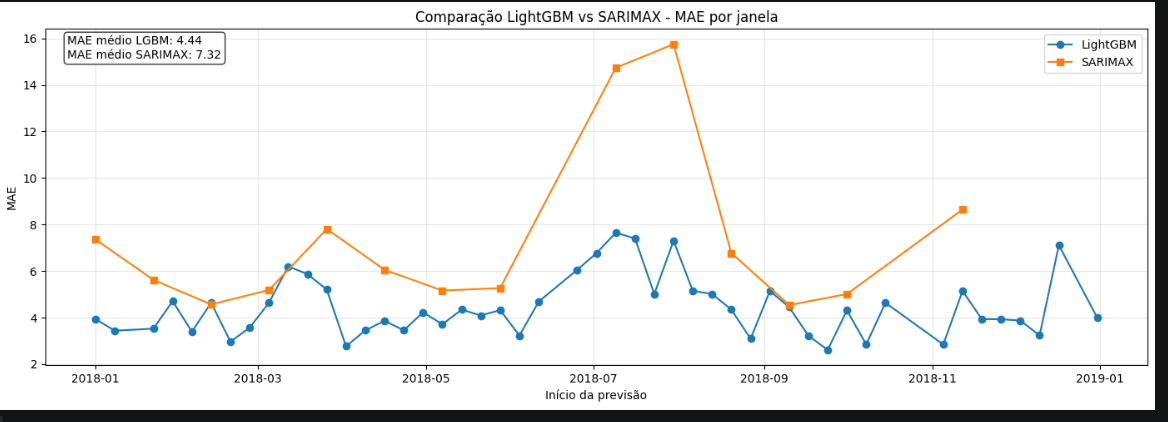

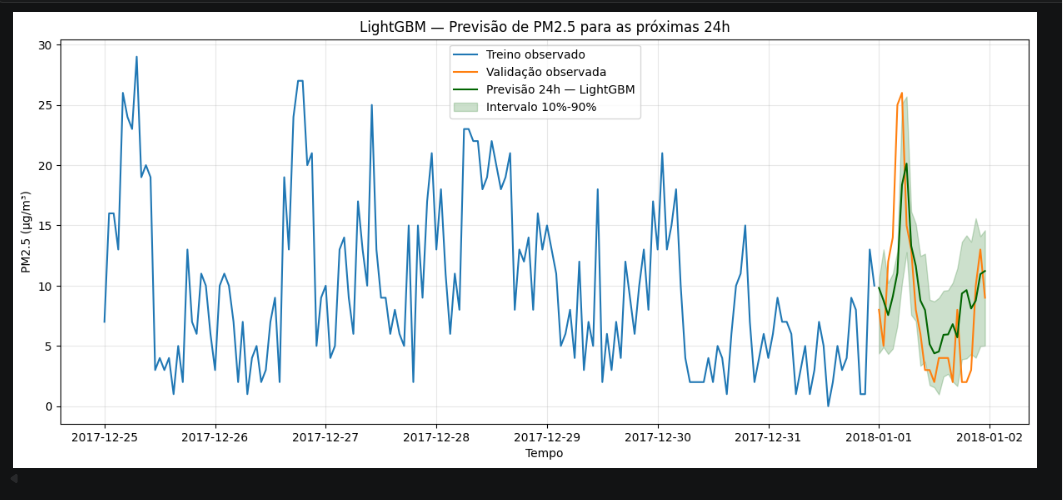

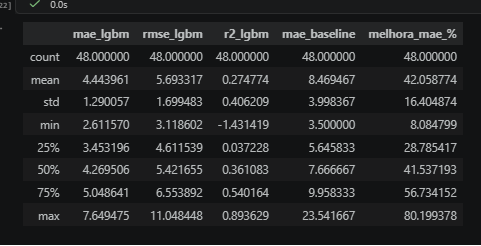

Experimento 02:

met_vars = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
]

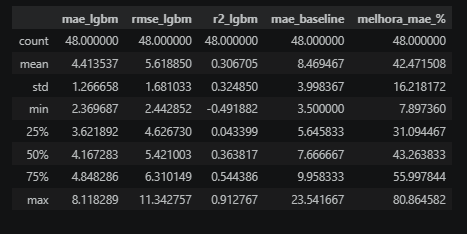


Experimento 03:

met_vars = [
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
]

Tirando séries de Fouruier


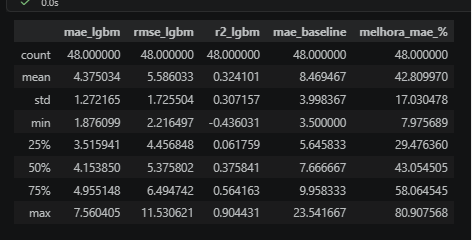

Experimento 04: -------------------------------------- > melhor

Aumentando lags de variáveis atmosféricas: [1, 3, 6, 12, 24]

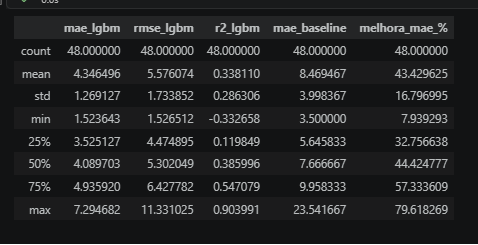

Experimento 05: 

Aumentando lags de variáveis atmosféricas:[1, 2, 3, 6, 12, 24]

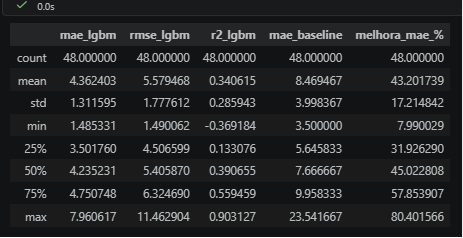

Experimento 06:
Tirei a variável de inverno e Aumentando lags de variáveis atmosféricas:[1, 3, 6, 12, 24] (resultado mais equilibrado)

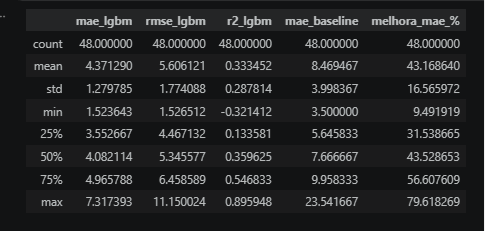

Experimento 07:
Com variável de inverno, adicionei lag temporal futuro. 


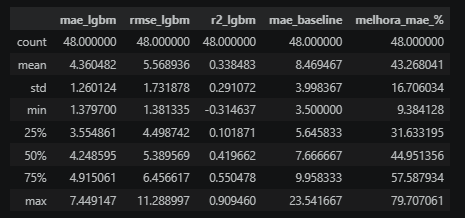